# ACT-Africa 2026 Hackathon

This notebook:

- Mounts Google Drive at `/content/drive`
- Uses `/content/drive/MyDrive/Colab Notebooks/ACT-Africa2026`
- Imports the required Python packages
- Import data and splits the dataset into Train/Val/Test
- Trains networks and rf with with different params
- Evaluates all models on `Test_Data`
- Displays the results with best params


**Import Necessary Libraries**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import shap
import joblib
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from scipy.stats import t
import tensorflow as tf
import itertools

# --------------------------
# Reproducibility and paths
# --------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

TARGET_COL = "Temp(oC)"     # Keep the leading space exactly as in the CSV

print("Libraries imported successfully.")

Libraries imported successfully.


**Import Data**

In [ ]:
# Mount Google Drive and configure paths
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/ACT-Africa2026"
TRAIN_FILE = f"{PROJECT_DIR}/Train_Data.csv"
TEST_FILE = f"{PROJECT_DIR}/Test_Data.csv"
OUTPUT_DIR = f"{PROJECT_DIR}/TrainedNetworks_hack"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Training file:", TRAIN_FILE)
print("Test file:", TEST_FILE)
print("Output directory:", OUTPUT_DIR)

if not os.path.isfile(TRAIN_FILE):
    raise FileNotFoundError(f"Training file not found: {TRAIN_FILE}")

if not os.path.isfile(TEST_FILE):
    raise FileNotFoundError(f"Test file not found: {TEST_FILE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026
Training file: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/Train_Data.csv
Test file: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/Test_Data.csv
Output directory: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack


**RF Functions**

In [ ]:
# ---------------------------------------------------------------------------
# Random Forest Optimization with Grid Search
# ---------------------------------------------------------------------------
def gridsearch_random_forest(X_train, y_train, X_test, y_test):
    param_grid = {
        'n_estimators': [10, 50],#, 100, 150, 200],
        'max_depth': [10, 20]#, 30, 50],
        #'min_samples_split': [2, 4],#, 6, 8, 10],
        #'min_samples_leaf': [1, 2]#, 3, 4, 5],
        #'max_features': ['auto', 'sqrt', 'log2']
    }

    rf = RandomForestRegressor(random_state=42)
    grid = GridSearchCV(rf, param_grid, cv=3, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_rf = grid.best_estimator_
    y_pred = best_rf.predict(X_test)
    results_df = pd.DataFrame(grid.cv_results_)

    results = evaluate_model(y_test, y_pred, "RandomForestRegressor (GridSearch)")
    best_params = grid.best_params_

    # ---------------------------------------------------------------------------
    # Print GS results using Bar chart
    # ---------------------------------------------------------------------------
    # Keep useful result fields and rank best-to-worst
    param_cols = [c for c in results_df.columns if c.startswith("param_")]

    plot_df = results_df[
        param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]
    ].copy().sort_values("mean_test_score", ascending=True)

    # Create a readable label for each parameter combination
    plot_df["Configuration"] = plot_df.apply(
        lambda row: (
            f"n={row['param_n_estimators']}, "
            f"depth={row['param_max_depth']}"
        ),
        axis=1
    )

    # Plot all combinations
    plt.figure(figsize=(14, max(8, len(plot_df) * 0.35)))

    colors = [
        "crimson" if rank == 1 else "steelblue"
        for rank in plot_df["rank_test_score"]
    ]

    bars = plt.barh(
        plot_df["Configuration"],
        plot_df["mean_test_score"],
        xerr=plot_df["std_test_score"],
        color=colors,
        edgecolor="black",
        alpha=0.85,
        capsize=3
    )

    plt.xlabel("Validation R² Score")
    plt.ylabel("Random Forest Hyperparameter Configuration")
    plt.title("Grid Search Results: Random Forest Configurations")

    # Display score on each bar
    for bar, score in zip(bars, plot_df["mean_test_score"]):
        plt.text(
            bar.get_width() + 0.00002,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.5f}",
            va="center",
            fontsize=8
        )

    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()

    # Save high-quality copy
    chart_file = os.path.join(OUTPUT_DIR, "gridsearch_results_bar_chart.png")
    plt.savefig(chart_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Bar chart saved to:", chart_file)

    return best_rf, best_params, results

# ---------------------------------------------------------------------------
# Train Optimized RandomForestRegressor Model
# ----------------------------------------------------------------------------
def train_random_forest_optimized(X_train, y_train, X_test, y_test, n_estimators, max_depth):

    # Train Random Forest on scaled targets
    rf = RandomForestRegressor(n_estimators=n_estimators,
                               max_depth=max_depth,
                               random_state=42
                    )

    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Save model to pkl
    model_filename = os.path.join(OUTPUT_DIR, "optimized_rf_model.pkl")
    with open(model_filename, 'wb') as file:
         pickle.dump(rf, file)
    print(f"Model saved successfully to {model_filename}")
    print("Model training complete.")

    # Return performance
    print("Evaluating trained model...")
    results = evaluate_model(y_test, y_pred, "RandomForestRegressor")
    print("Evaluation complete.")

    # Plotting results
    # Use the last 100 samples from the test set
    n_last = 100
    X_slice = X_test[-n_last:]
    Y_slice = y_test.iloc[-n_last:]

    # Predict using the trained Random Forest model
    y_pred_slice = rf.predict(X_slice)
    y_true_slice = Y_slice.values       # Get numpy array from Series

    # Get predictions from each tree to estimate uncertainty
    tree_preds = np.array([tree.predict(X_slice) for tree in rf.estimators_])  # (n_trees, n_last)

    # Mean and std across trees for each sample
    mean_pred = tree_preds.mean(axis=0)        # (n_last,)
    std_pred  = tree_preds.std(axis=0)         # (n_last,)

    # Approximate 95% interval: mean ± 1.96 * std
    lower_95 = mean_pred - 1.96 * std_pred
    upper_95 = mean_pred + 1.96 * std_pred

    # Plot
    idx = np.arange(1, n_last + 1)

    plt.figure(figsize=(14, 6))

    # Actual and predicted
    plt.plot(idx, y_true_slice, marker='o', linewidth=2, label='Actual')
    plt.plot(idx, y_pred_slice, marker='s', linewidth=2, label='Predicted')

    # 95% interval using mean ± 1.96 * std
    plt.fill_between(
        idx, lower_95, upper_95,
        color='gray', alpha=0.3, label='95% CI (±1.96σ)'
    )

    plt.xlabel('Last 100 Test Samples')
    plt.ylabel('Temperature (°C)')
    plt.title('Actual vs Predicted for Last 100 Test Samples (Random Forest, 95% CI)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    chart_file = os.path.join(OUTPUT_DIR, "predicted_vs_actual_plot.png")
    plt.savefig(chart_file, dpi=300, bbox_inches="tight")

    return {"model": rf, "name": "RandomForest", "y_pred": y_pred}, {"Performance": results}

# ---------------------------------------------------------------------------
# Model Performance Evaluation Metrics
# ---------------------------------------------------------------------------
def evaluate_model(y_true, y_pred, model_name):
    r2 = np.round(r2_score(y_true, y_pred), 4)
    rmse = np.round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    mae = np.round(mean_absolute_error(y_true, y_pred), 4)
    return {"Model": model_name, "R2": r2, "RMSE": rmse, "MAE": mae}

**Train/Val/Test Split**

In [ ]:
train_data = pd.read_csv(TRAIN_FILE)
test_data = pd.read_csv(TEST_FILE)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# --- Create Dependent and Indipendent Variables ---
X = test_data.drop(["Temp(oC)"], axis=1)
Y = test_data['Temp(oC)']

print("IV:", X.shape)
print("DV:", Y.shape)

# First split: 70% train, 30% temp (val+test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=None, shuffle=True )

# Second split: of the 30%, take 15/30 = 0.5 for val, rest for test
# So val = 15% of total, test = 15% of total
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=None, shuffle=False
)

# Fit scaler ONLY on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_val   = scaler.transform(X_val)         # transform only
X_test  = scaler.transform(X_test)        # transform only
scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

print(f"Train samples: {X_train.shape}")
print(f"Validation samples: {X_val.shape}")
print(f"Test samples: {X_test.shape}")


Train data shape: (1048575, 7)
Test data shape: (519310, 7)
IV: (519310, 6)
DV: (519310,)
Scaler saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/scaler.pkl
Train samples: (363517, 6)
Validation samples: (77896, 6)
Test samples: (77897, 6)


Running grid search on RF...


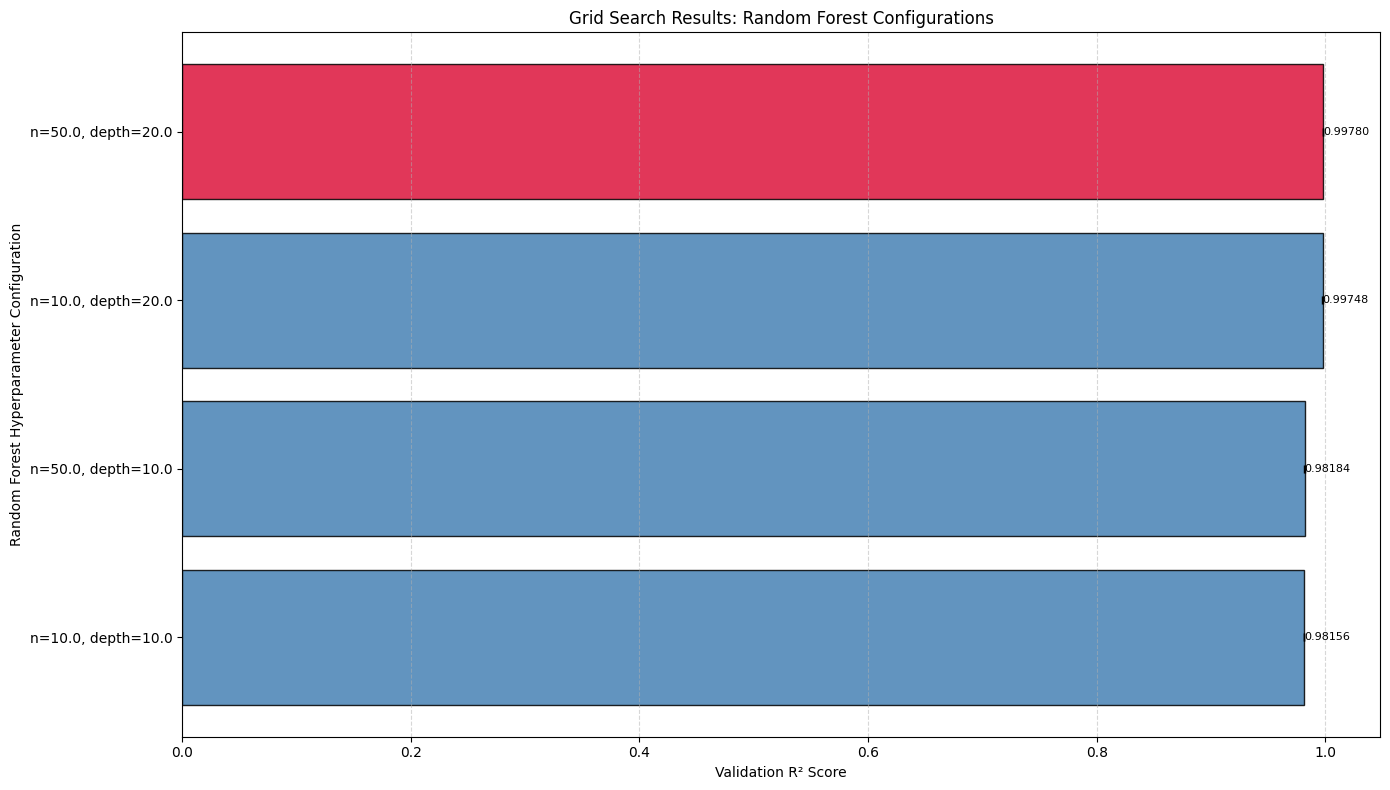

Bar chart saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/gridsearch_results_bar_chart.png
Grid Search Results:
{'Model': 'RandomForestRegressor (GridSearch)', 'R2': np.float64(0.9982), 'RMSE': np.float64(1.0677), 'MAE': np.float64(0.703)}
Grid search complete.


In [ ]:
# GridSearchCV for RandomForest
print("Running grid search on RF...")
best_rf, best_params, grid_results = gridsearch_random_forest(X_train, Y_train, X_val, Y_val)
print("Grid Search Results:")
print(grid_results)
print("Grid search complete.")

**Train Optimized Model**

Model training started...
Model saved successfully to /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/optimized_rf_model.pkl
Model training complete.
Evaluating trained model...
Evaluation complete.


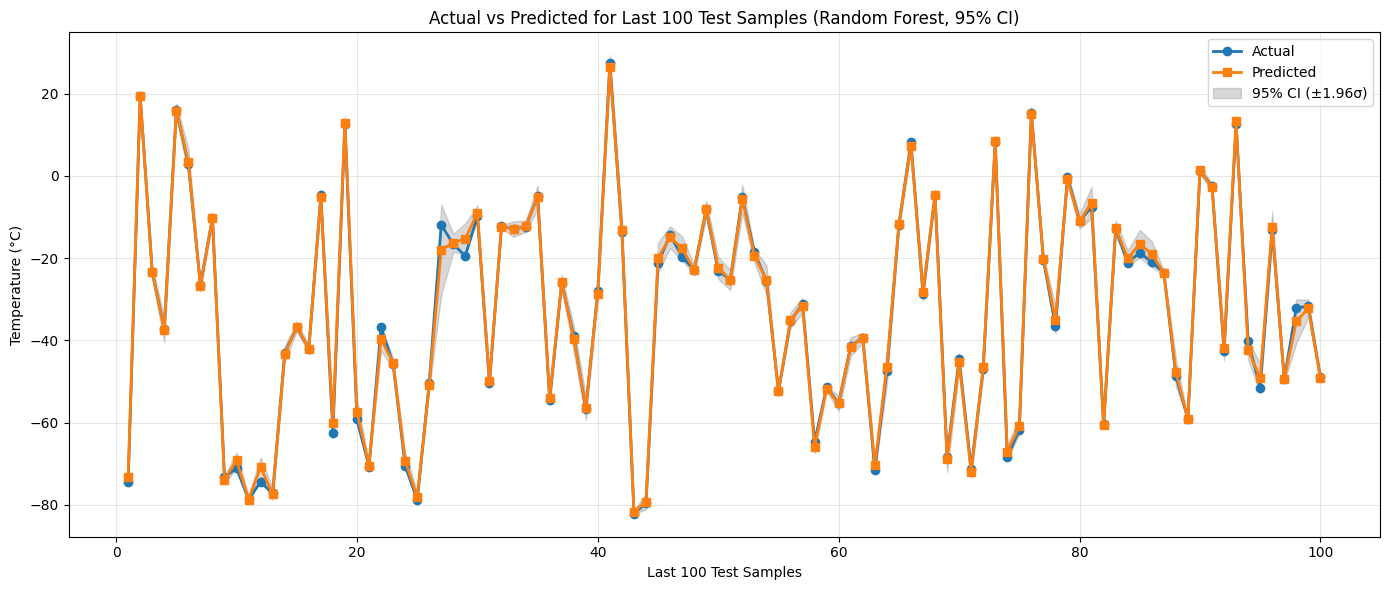

Model Performance:
{'Performance': {'Model': 'RandomForestRegressor', 'R2': np.float64(0.9983), 'RMSE': np.float64(1.0642), 'MAE': np.float64(0.7013)}}


<Figure size 640x480 with 0 Axes>

In [ ]:
# train optimized model
print("Model training started...")
best_info, rf_results  = train_random_forest_optimized(X_train, Y_train, X_test, Y_test,
                                                       best_params['n_estimators'],
                                                       best_params['max_depth'])
print("Model Performance:")
print(rf_results)

**ANN**

Running 8 ANN configurations...
HPO training sample size: 100,000
[01/8] optimizer=adam, lr=0.01, epochs=10
[02/8] optimizer=rmsprop, lr=0.01, epochs=10
[03/8] optimizer=adam, lr=0.01, epochs=15


[04/8] optimizer=rmsprop, lr=0.01, epochs=15
[05/8] optimizer=adam, lr=0.001, epochs=10
[06/8] optimizer=rmsprop, lr=0.001, epochs=10
[07/8] optimizer=adam, lr=0.001, epochs=15
[08/8] optimizer=rmsprop, lr=0.001, epochs=15

Best ANN parameters:
{'run': 5, 'optimizer': 'adam', 'learning_rate': 0.001, 'max_epochs': 10, 'epochs_trained': 10, 'val_rmse': 33.30948782176268, 'val_mae': 27.328286564130003, 'val_r2': -0.7059389116458081, 'rank': 1}

All ANN Grid-Search Results:


,run,optimizer,learning_rate,max_epochs,epochs_trained,val_rmse,val_mae,val_r2,rank
0,5,adam,0.001,10,10,33.309488,27.328287,-0.705939,1
1,6,rmsprop,0.001,10,10,30.979540,25.397197,-0.475630,2
2,7,adam,0.001,15,15,26.766686,22.136445,-0.101582,3
3,8,rmsprop,0.001,15,15,26.602069,22.063873,-0.088074,4
4,1,adam,0.010,10,10,25.473780,21.245029,0.002267,5
5,3,adam,0.010,15,15,25.262351,21.016964,0.018760,6
6,2,rmsprop,0.010,10,10,21.222710,17.347473,0.307485,7
7,4,rmsprop,0.010,15,15,12.911819,10.390846,0.743668,8


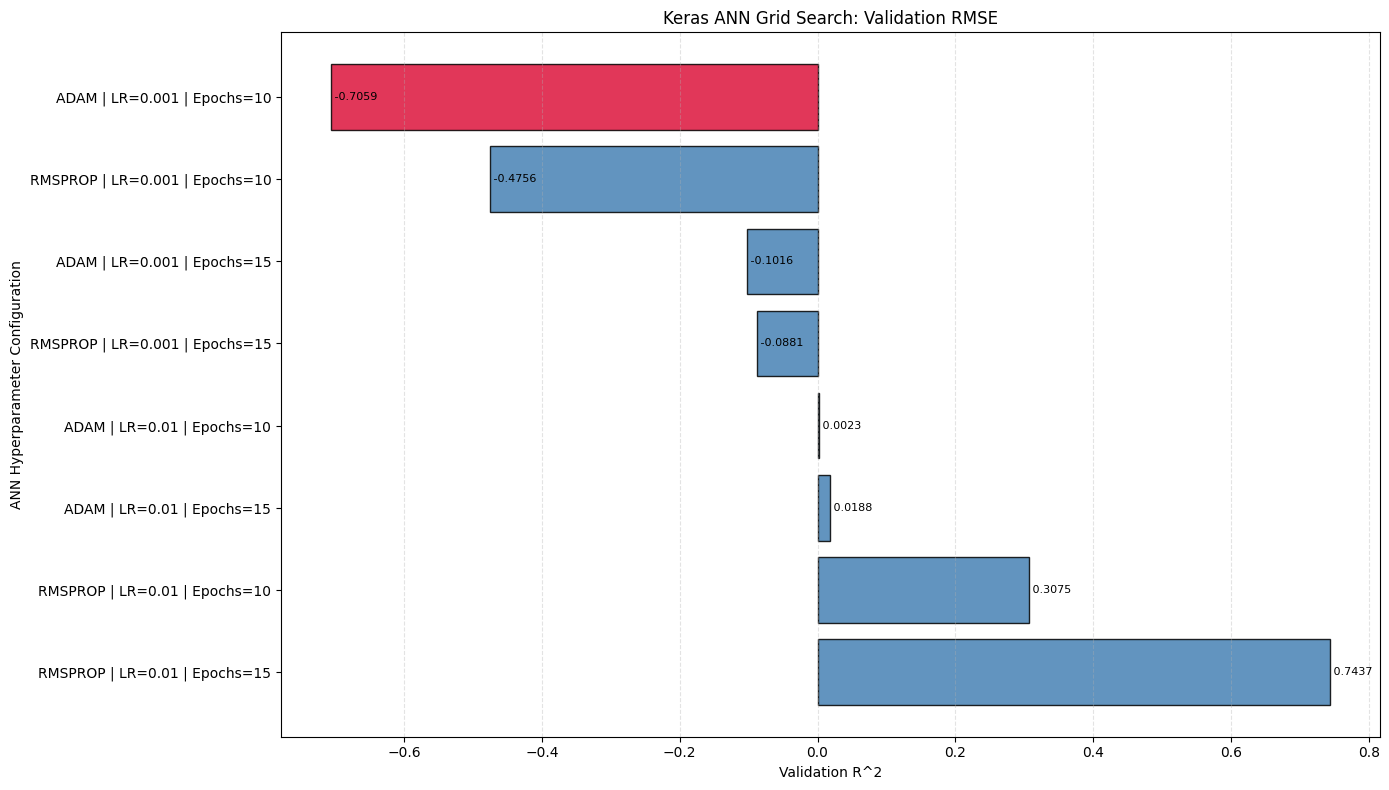

Grid-search chart saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/keras_ann_grid_search_bar_chart.png
Grid-search results saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/keras_ann_grid_search_results.csv
Epoch 1/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 843.9027 - mae: 23.7842 - rmse: 29.0500 
Epoch 2/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 347.9395 - mae: 13.9513 - rmse: 18.6531
Epoch 3/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 102.6264 - mae: 6.7136 - rmse: 10.1305
Epoch 4/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44.2598 - mae: 4.9878 - rmse: 6.6528
Epoch 5/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 31.8724 - mae: 4.2992 - rmse: 5.6456
Epoch 6/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27.3613 - mae: 3.9858 - rmse: 5.2308
Epoch 7/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24.7918 - mae: 3.7946 - rmse: 4.9791
Epoch 8/10
432/432 ━━━━━━━━━━━━━━━

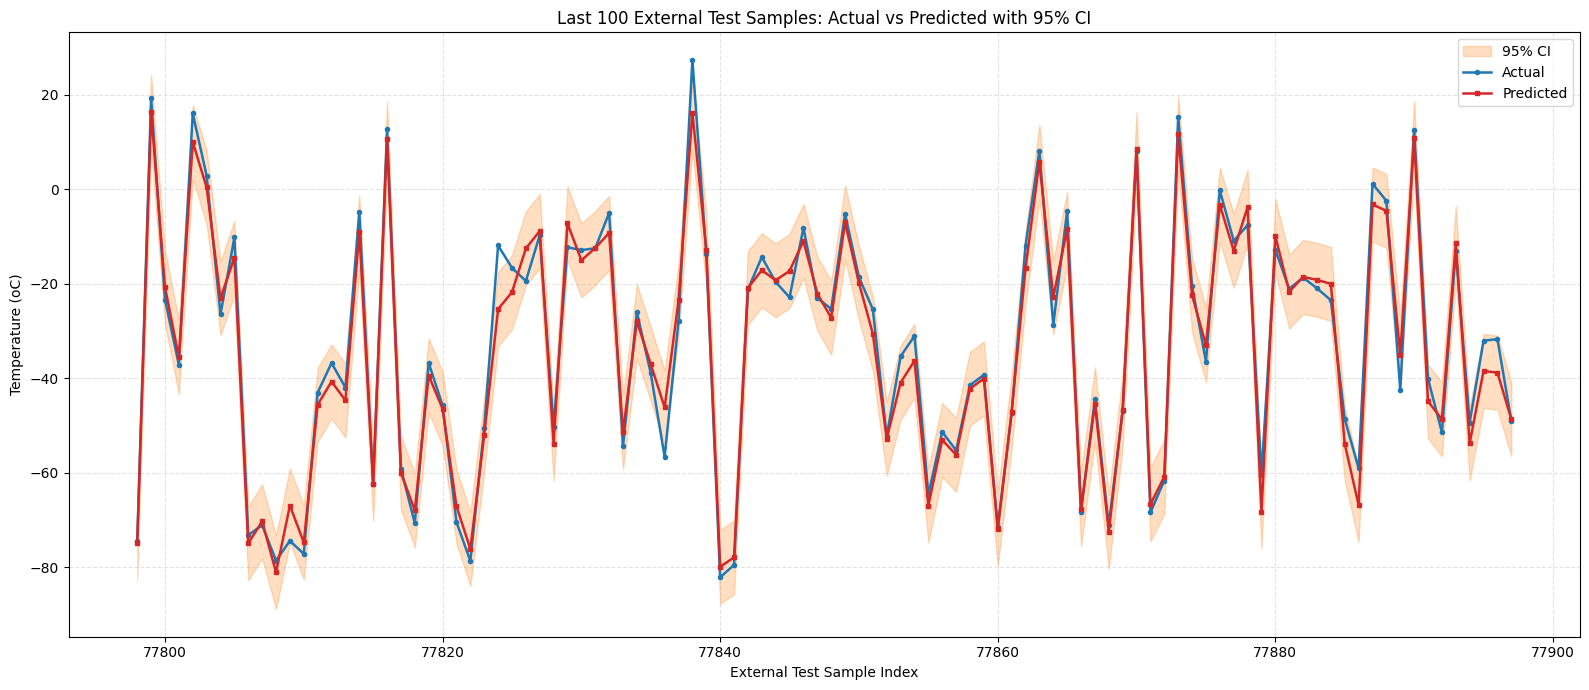

Actual vs predicted chart saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/keras_ann_last_100_actual_predicted_95CI.png
Last-100 prediction values saved to: /content/drive/MyDrive/Colab Notebooks/ACT-Africa2026/TrainedNetworks_hack/keras_ann_last_100_predictions_95CI.csv


In [ ]:
# --------------------------
# Build ANN model
# --------------------------
def build_keras_ann(input_dim, learning_rate=0.001, optimizer_name="adam"):
    """Create and compile a regression ANN."""

    optimizer_map = {
        "adam": tf.keras.optimizers.Adam(learning_rate=learning_rate),
        "rmsprop": tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
        "sgd": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    }

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.10),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=optimizer_map[optimizer_name],
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"]
    )
    return model

# --------------------------
# ANN grid-search function
# --------------------------
def optimize_keras_ann(
    X_train, y_train, X_val, y_val,
    learning_rates=(0.01, 0.001),
    epochs_list=(10, 20),
    optimizers=("adam", "rmsprop"),
    batch_size=16384,
    max_hpo_train_samples=100000
):
    """
    Evaluate every learning-rate, epoch, optimizer combination.
    HPO uses a representative sample to keep runtime manageable.
    """

    # Sample only the training portion for quick HPO; validation stays unchanged.
    rng = np.random.default_rng(SEED)
    n_hpo = min(max_hpo_train_samples, len(X_train))
    sample_idx = rng.choice(len(X_train), size=n_hpo, replace=False)

    X_hpo = X_train[sample_idx]
    y_hpo = y_train.iloc[sample_idx] # Fixed: Use .iloc for positional indexing on Series

    combinations = list(itertools.product(
        learning_rates, epochs_list, optimizers
    ))

    all_results = []

    print(f"Running {len(combinations)} ANN configurations...")
    print(f"HPO training sample size: {len(X_hpo):,}")

    for run, (lr, epochs, optimizer_name) in enumerate(combinations, start=1):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)

        print(
            f"[{run:02d}/{len(combinations)}] "
            f"optimizer={optimizer_name}, lr={lr}, epochs={epochs}"
        )

        model = build_keras_ann(
            input_dim=X_train.shape[1],
            learning_rate=lr,
            optimizer_name=optimizer_name
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        )

        history = model.fit(
            X_hpo, y_hpo,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        val_pred = model.predict(X_val, batch_size=batch_size, verbose=0).ravel()

        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        val_mae = mean_absolute_error(y_val, val_pred)
        val_r2 = r2_score(y_val, val_pred)

        all_results.append({
            "run": run,
            "optimizer": optimizer_name,
            "learning_rate": lr,
            "max_epochs": epochs,
            "epochs_trained": len(history.history["loss"]),
            "val_rmse": val_rmse,
            "val_mae": val_mae,
            "val_r2": val_r2
        })

    results_df = pd.DataFrame(all_results).sort_values(
        "val_r2", ascending=True
    ).reset_index(drop=True)

    results_df["rank"] = np.arange(1, len(results_df) + 1)

    best_params = results_df.iloc[0].to_dict()

    print("\nBest ANN parameters:")
    print(best_params)

    return best_params, results_df

# --------------------------
# Plot all HPO results
# --------------------------
def plot_ann_grid_search_results(results_df, output_dir):
    """Create a horizontal bar chart of all ANN grid-search trials."""

    plot_df = results_df.sort_values("val_rmse", ascending=True).copy()

    plot_df["configuration"] = (
        plot_df["optimizer"].str.upper()
        + " | LR=" + plot_df["learning_rate"].astype(str)
        + " | Epochs=" + plot_df["max_epochs"].astype(str)
    )

    colors = [
        "crimson" if rank == 1 else "steelblue"
        for rank in plot_df["rank"]
    ]

    plt.figure(figsize=(14, max(8, len(plot_df) * 0.35)))
    bars = plt.barh(
        plot_df["configuration"],
        plot_df["val_r2"],
        color=colors,
        edgecolor="black",
        alpha=0.85
    )

    plt.xlabel("Validation R^2")
    plt.ylabel("ANN Hyperparameter Configuration")
    plt.title("Keras ANN Grid Search: Validation RMSE")

    for bar, score in zip(bars, plot_df["val_r2"]):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {score:.4f}",
            va="center",
            fontsize=8
        )

    plt.grid(axis="x", linestyle="--", alpha=0.35)
    plt.tight_layout()

    fig_path = os.path.join(output_dir, "keras_ann_grid_search_bar_chart.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    results_path = os.path.join(output_dir, "keras_ann_grid_search_results.csv")
    results_df.to_csv(results_path, index=False)

    print("Grid-search chart saved to:", fig_path)
    print("Grid-search results saved to:", results_path)

# --------------------------
# Train final best ANN
# --------------------------
def train_final_keras_ann(
    X_train, y_train, X_val, y_val, X_test, y_test,
    best_params, batch_size=16384
):
    """Train the selected ANN on train data and assess it on Test_Data."""
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    # Combine train and validation data for final model training
    X_final_train = np.vstack([X_train, X_val])
    y_final_train = np.concatenate([y_train, y_val])

    model = build_keras_ann(
        input_dim=X_final_train.shape[1],
        learning_rate=float(best_params["learning_rate"]),
        optimizer_name=best_params["optimizer"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        X_final_train, y_final_train,
        epochs=int(best_params["max_epochs"]),
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred = model.predict(X_test, batch_size=batch_size, verbose=0).ravel()

    metrics = {
        "Test_RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "Test_MAE": float(mean_absolute_error(y_test, y_pred)),
        "Test_R2": float(r2_score(y_test, y_pred)),
        "Epochs_Trained": len(history.history["loss"])
    }

    return model, y_pred, metrics, history

# --------------------------
# Last-100 actual/predicted plot
# --------------------------
def plot_last_100_actual_vs_predicted(y_test, y_pred, output_dir, target_name="Temp(oC)"):
    """
    Plot the last 100 external test predictions.
    The band is a 95% residual-based prediction interval around y_pred.
    """

    n_last = min(100, len(y_test))

    actual = np.asarray(y_test).ravel()[-n_last:]
    predicted = np.asarray(y_pred).ravel()[-n_last:]

    residuals = np.asarray(y_test).ravel() - np.asarray(y_pred).ravel()
    dof = max(len(residuals) - 1, 1)
    residual_std = np.sqrt(np.sum(residuals ** 2) / dof)
    ci_95 = t.ppf(0.975, dof) * residual_std

    lower_bound = predicted - ci_95
    upper_bound = predicted + ci_95
    sample_number = np.arange(len(y_test) - n_last + 1, len(y_test) + 1)

    plt.figure(figsize=(16, 7))

    plt.fill_between(
        sample_number, lower_bound, upper_bound,
        color="tab:orange", alpha=0.25,
        label="95% CI"
    )
    plt.plot(
        sample_number, actual,
        color="tab:blue", linewidth=1.8,
        marker="o", markersize=3,
        label="Actual"
    )
    plt.plot(
        sample_number, predicted,
        color="tab:red", linewidth=1.8,
        marker="s", markersize=3,
        label="Predicted"
    )

    plt.xlabel("External Test Sample Index")
    plt.ylabel(target_name)
    plt.title("Last 100 External Test Samples: Actual vs Predicted with 95% CI")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(
        output_dir, "keras_ann_last_100_actual_predicted_95CI.png"
    )
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Actual vs predicted chart saved to:", plot_path)

    return pd.DataFrame({
        "sample_index": sample_number,
        "actual": actual,
        "predicted": predicted,
        "lower_95_ci": lower_bound,
        "upper_95_ci": upper_bound
    })


#Grid search: 3 learning rates x 3 epoch values x 3 optimizers = 27 runs
best_ann_params, ann_grid_results = optimize_keras_ann(
    X_train, Y_train, X_val, Y_val,
    learning_rates=(0.01, 0.001),
    epochs_list=(10, 15),
    optimizers=("adam", "rmsprop"),
    batch_size=16384,
    max_hpo_train_samples=100000
)

print("\nAll ANN Grid-Search Results:")
display(ann_grid_results)

# Grid-search bar chart and CSV
plot_ann_grid_search_results(ann_grid_results, OUTPUT_DIR)

# Train final model and evaluate on the independent Test_Data.csv
best_ann_model, y_test_pred_ann, ann_test_metrics, ann_history = train_final_keras_ann(
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test,
    best_ann_params,
    batch_size=1024
)

print("\nFinal Keras ANN Test Results:")
for metric_name, metric_value in ann_test_metrics.items():
    print(f"{metric_name}: {metric_value:.6f}" if isinstance(metric_value, float)
          else f"{metric_name}: {metric_value}")

# E. Save model, scaler, metrics, and prediction results
model_path = os.path.join(OUTPUT_DIR, "best_keras_ann_model.keras")
scaler_path = os.path.join(OUTPUT_DIR, "keras_ann_scaler.pkl")
metrics_path = os.path.join(OUTPUT_DIR, "keras_ann_test_metrics.csv")

best_ann_model.save(model_path)
scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")


pd.DataFrame([ann_test_metrics]).to_csv(metrics_path, index=False)

print("\nSaved ANN model:", model_path)
print("Saved scaler:", scaler_path)
print("Saved test metrics:", metrics_path)

# F. Last 100 observations: actual vs predicted + 95% interval
last_100_results = plot_last_100_actual_vs_predicted(
    Y_test,
    y_test_pred_ann,
    OUTPUT_DIR,
    target_name="Temperature (oC)"
)

last_100_csv = os.path.join(
    OUTPUT_DIR, "keras_ann_last_100_predictions_95CI.csv"
)
last_100_results.to_csv(last_100_csv, index=False)

print("Last-100 prediction values saved to:", last_100_csv)